In [1]:
from os import makedirs

from matplotlib import pyplot as plt
from matplotlib import rc, rcParams, patches
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, normalize

from helpers.data import *
from helpers.plots import multisavefig, tandem_heatmap, mutation_context_barplot, position_barplots, heatmap_and_inversions, pieplot_mut_type
from helpers.bio import get_aid_pattern, reverse_complement_from_str, tandem_canonizer, dataframe_canonizer

In [2]:
# output dirs
makedirs("output/", exist_ok=True)

for t in ["eps", "pdf", "png"]:
    makedirs(f"figs/{t}/", exist_ok=True)
# figure styling
sns.set_context("paper", font_scale=0.83, rc={"lines.linewidth": 2})
rc("font", **{"family": "sans-serif", "sans-serif": ["Arial"]})
rcParams['ps.fonttype'] = 42

In [3]:
#%load_ext rpy2.ipython

In [4]:
# %%R
# suppressMessages(source("helpers/plots.R"))
# suppressMessages(source("helpers/data.R"))
# suppressMessages(library("dplyr"))
# suppressMessages(library("tidyverse"))
# suppressMessages(library("magrittr"))
# suppressMessages(library("pheatmap"))
# suppressMessages(library(ComplexHeatmap))
# suppressMessages(library(corrplot))
# suppressMessages(library(extrafont))
# suppressMessages(loadfonts(device = "postscript"))

## Load and preprocess data
## IGV Leiden

In [5]:
tandem_fulltable_bysub_leiden_igv = load_tandem_info(
    "data/leiden_observed_tandems_IGV.tsv",
    "data/leiden_simulation_IGV_count_mutation_context.tsv"
)

# some tables ready to use them later
tandem_bysub_leiden_igv = get_corrected_df(tandem_fulltable_bysub_leiden_igv, ["ref", "alt"])
tandem_bysub_leiden_igv.to_csv("output/tandem_bysub_leiden_igv.csv")
tandem_bysubcxt_leiden_igv = get_corrected_df(tandem_fulltable_bysub_leiden_igv, ["ref", "alt", "context"])

# add aid motifs in each position to tandems
tandem_bysubcxt_leiden_igv["aid_motif_pos1"] = tandem_bysubcxt_leiden_igv.apply(
    lambda x: get_aid_pattern(x.ref, x.alt, x.context, pos=0), axis=1
)
tandem_bysubcxt_leiden_igv["aid_motif_pos2"] = tandem_bysubcxt_leiden_igv.apply(
    lambda x: get_aid_pattern(x.ref, x.alt, x.context, pos=1), axis=1
)

## IGVH Leiden

In [6]:
tandem_fulltable_bysub_leiden_igh = load_tandem_info(
    "data/leiden_observed_tandems_IGHV.tsv",
    "data/leiden_simulation_IGHV_count_mutation_context.tsv"
)

# some tables ready to use them later
tandem_bysub_leiden_igh = get_corrected_df(tandem_fulltable_bysub_leiden_igh, ["ref", "alt"])
tandem_bysubcxt_leiden_igh = get_corrected_df(tandem_fulltable_bysub_leiden_igh, ["ref", "alt", "context"])

# add aid motifs in each position to tandems
tandem_bysubcxt_leiden_igh["aid_motif_pos1"] = tandem_bysubcxt_leiden_igh.apply(
    lambda x: get_aid_pattern(x.ref, x.alt, x.context, pos=0), axis=1
)
tandem_bysubcxt_leiden_igh["aid_motif_pos2"] = tandem_bysubcxt_leiden_igh.apply(
    lambda x: get_aid_pattern(x.ref, x.alt, x.context, pos=1), axis=1
)

## IGH Leiden no corrected 

In [7]:
igh_nc = pd.read_csv("data/leiden_observed_tandems_IGHV_20nt.tsv", sep="\t")
igh_nc = igh_nc.query("size == 2")

In [8]:
igh_nc_pr = (
    igh_nc.assign(
        tandem=lambda x: x.ref + ">" + x.alt,
        germ=lambda x: x.context.str.extract(r"(.{,3}\.{2}.{,3})"),
        germ4=lambda x: x.germ.str[2:3] +x.ref + x.germ.str[5:6],
        germ4_pupy = lambda x: x.germ4.str[0:1] + x.germ4.str[3:4],
        germ6=lambda x: x.germ.str[1:3] +x.ref + x.germ.str[5:7],
        germ8=lambda x: x.germ.str[0:3] +x.ref + x.germ.str[5:8],
        alt_germ4=lambda x: x.apply(lambda y: y.germ4.find(y.alt), axis=1),
        alt_germ6=lambda x: x.apply(lambda y: y.germ6.find(y.alt), axis=1),
        alt_germ8=lambda x: x.apply(lambda y: y.germ8.find(y.alt), axis=1),
        alt_germ20=lambda x: x.apply(lambda y: y.context.find(y.alt), axis=1),
        up10=lambda x: x.ref.str[2::-1] + x.context.str[19::-1],
        dw10=lambda x: x.ref + x.context.str[22:42],
        c_up=lambda x: x.up10.str.find("C"),
        g_dw=lambda x: x.dw10.str.find("G"),
        
    )
    .groupby(["tandem","context","germ","c_up","g_dw","germ4","germ4_pupy","germ6","germ8","alt_germ8","alt_germ6","alt_germ4","alt_germ20"])
    .size().to_frame("n")
    .reset_index()

)

igh_nc_pr.head()

,tandem,context,germ,c_up,g_dw,germ4,germ4_pupy,germ6,germ8,alt_germ8,alt_germ6,alt_germ4,alt_germ20,n
0,AA>CG,AATACTATGCAGACTCCGTG..GGGCCGATTCACCATCTCCA,GTG..GGG,5,2,GAAG,GG,TGAAGG,GTGAAGGG,-1,-1,-1,16,1
1,AA>CG,CCAACTACAACCCCTCCCTC..GAGTCGAGTCACCATATCAG,CTC..GAG,2,2,CAAG,CG,TCAAGA,CTCAAGAG,-1,-1,-1,26,1
2,AA>CG,CCAAGAACCAGTTCTCCCTG..GCTGAGCTCTGTGACCGCCG,CTG..GCT,4,2,GAAG,GG,TGAAGC,CTGAAGCT,-1,-1,-1,37,1
3,AA>CG,CCATATCAGTAGACACGTCC..GAACCAGTTCTCCCTGAAGC,TCC..GAA,2,2,CAAG,CG,CCAAGA,TCCAAGAA,-1,-1,-1,15,1
4,AA>CG,TATGGTATGATGGAAGTAAT..ATACTATGCAGACTCCGTGA,AAT..ATA,-1,9,TAAA,TA,ATAAAT,AATAAATA,-1,-1,-1,37,1


In [9]:
# df no corrected
tandem_bysubcxt_leiden_igh_nc = (
    igh_nc.assign(
        context=lambda x: x.context.str.extract(r"(.{,2}\.{2}.{,2})"),
    )
    .groupby(["ref","alt","context","size"])
    .size().to_frame("n")
    .reset_index()

)

## IGV MSH Rotterdam

In [10]:
tandem_fulltable_bysub_rotterdam_msh = load_tandem_info(
    "data/rotterdam_msh_observed_tandems_IGHV.tsv",
    "data/rotterdam_msh_simulation_IGHV_count_mutation_context.tsv"
)

tandem_bysub_rotterdam_msh = get_corrected_df(tandem_fulltable_bysub_rotterdam_msh, ["ref", "alt"])
tandem_bysub_rotterdam_msh.to_csv("output/tandem_bysub_rotterdam_msh.csv")

## IGV UNG Rotterdam

In [11]:
tandem_fulltable_bysub_rotterdam_ung = load_tandem_info(
    "data/rotterdam_ung_observed_tandems_IGHV.tsv",
    "data/rotterdam_ung_simulation_IGHV_count_mutation_context.tsv"
)

# With correction
#tandem_bysub_rotterdam_ung = get_corrected_df(tandem_fulltable_bysub_rotterdam_ung, ["ref", "alt"])

#without correction
tandem_bysub_rotterdam_ung_no_correc = tandem_fulltable_bysub_rotterdam_ung
tandem_bysub_rotterdam_ung_no_correc  = tandem_bysub_rotterdam_ung_no_correc.rename(columns={'n_obs': 'n'})

## IGV HD Rotterdam

In [12]:
tandem_fulltable_bysub_rotterdam_hd = load_tandem_info(
    "data/rotterdam_healthy_observed_tandems_IGHV.tsv",
    "data/rotterdam_healthy_simulation_IGHV_count_mutation_context.tsv"
)

tandem_bysub_rotterdam_hd = get_corrected_df(tandem_fulltable_bysub_rotterdam_hd, ["ref", "alt"])
tandem_bysub_rotterdam_hd.to_csv("output/tandem_bysub_rotterdam_hd.csv")

# Figures

## Fig Distribution

In [13]:
dbs_mutdata_igh = pd.read_csv("data/dns_analysis/dns_mutational_analysis_IgH.csv")

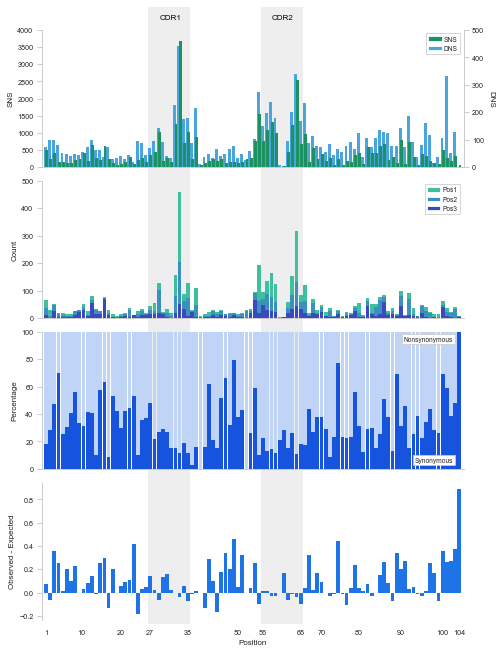

In [14]:
fig_1 = position_barplots(dbs_mutdata_igh, [1, 10, 20, 27, 38, 50, 56, 65, 70, 80, 90, 100, 104], [0.975, 0.975])

# invisible axis to draw things accross all the subplots
overax = fig_1.add_axes([0.1, 0.1, 0.845, 0.81])
overax.axis("off")
overax.set_zorder(-1)

# cdr1
overax.text(0.285, 0.98, "CDR1")
rect_cdr1 = patches.Rectangle((0.261, 0.025), 0.091, 0.975, color="#eeeeee", lw=0)
overax.add_patch(rect_cdr1)

# cdr2
overax.text(0.53, 0.98, "CDR2")
rect_cdr2 = patches.Rectangle((0.5063, 0.025), 0.091, 0.975, color="#eeeeee", lw=0)
overax.add_patch(rect_cdr2)

#multisavefig(fig_1, "figs/jem", "fig_1")
fig_1.set_size_inches((17.5+1.7)/2.54,(22.8+4.76)/2.54)
for i in ["eps", "png", "pdf"]:
    fig_1.savefig(f"figs/{i}/fig_2.{i}",bbox_inches='tight',pad_inches = 0.05)

## Fig Pie codon #without correction

In [15]:
# table_vdj = get_corrected_mut_type_table(
#     "data/leiden_observed_tandems_IGHV.tsv",
#     "data/leiden_simulation_IGHV_count_pos_aachange_framepos.tsv",
# ).assign(lymph="VDJ")
# table_igk = get_corrected_mut_type_table(
#     "data/leiden_observed_tandems_IGKV.tsv",
#     "data/leiden_simulation_IGKV_count_pos_aachange_framepos.tsv",
# ).assign(lymph="IGK")
# table_igl = get_corrected_mut_type_table(
#     "data/leiden_observed_tandems_IGLV.tsv",
#     "data/leiden_simulation_IGLV_count_pos_aachange_framepos.tsv",
# ).assign(lymph="IGL")

# # join the three tables
# df_mut_type = pd.concat([table_vdj, table_igk, table_igl], ignore_index=True)
# # filter out 0
# df_mut_type = df_mut_type[df_mut_type.n != 0]

In [16]:
#Without correction
table_vdj = get_mut_type_table_obs("data/leiden_observed_tandems_IGHV.tsv")
table_vdj["aid_motif"] = table_vdj.apply(lambda x: f"Pos{x.frame_pos} {x.mut_type}", axis=1)
table_vdj["perc"] = table_vdj.n / table_vdj.n.sum() * 100
table_vdj = table_vdj[["aid_motif", "n", "perc"]].assign(lymph="VDJ")

table_igk = get_mut_type_table_obs("data/leiden_observed_tandems_IGKV.tsv")
table_igk["aid_motif"] = table_igk.apply(lambda x: f"Pos{x.frame_pos} {x.mut_type}", axis=1)
table_igk["perc"] = table_igk.n / table_igk.n.sum() * 100
table_igk = table_igk[["aid_motif", "n", "perc"]].assign(lymph="IGK")

table_igl = get_mut_type_table_obs("data/leiden_observed_tandems_IGLV.tsv")
table_igl["aid_motif"] = table_igl.apply(lambda x: f"Pos{x.frame_pos} {x.mut_type}", axis=1)
table_igl["perc"] = table_igl.n / table_igl.n.sum() * 100
table_igl = table_igl[["aid_motif", "n", "perc"]].assign(lymph="IGL")

# join the three tables
df_mut_type = pd.concat([table_vdj, table_igk, table_igl], ignore_index=True)
# filter out 0
df_mut_type = df_mut_type[df_mut_type.n != 0]

In [17]:
mut_type_labels = ['Pos1 Nonsyn','Pos1 Nonsense','Pos2 Nonsyn', 'Pos2 Nonsense',
                   'Pos3 Nonsyn','Pos3 2x Nonsyn','Pos3 Syn','Pos3 Nonsense']
# set order
df_mut_type['aid_motif'] = pd.Categorical(df_mut_type.aid_motif, mut_type_labels)
df_mut_type.sort_values('aid_motif', inplace=True)

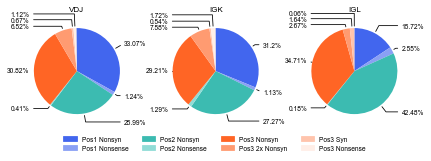

In [18]:
# the same again, but with spaces to put the labels as we want
mut_type_labels_mod = ['Pos1 Nonsyn','Pos1 Nonsense', 'Pos2 Nonsyn', 'Pos2 Nonsense',
                       'Pos3 Nonsyn','Pos3 2x Nonsyn','Pos3 Syn','Pos3 Nonsense']
yadjusts = [[1.3, 1.1, 1.2, 1.1, 0.4, 1.1, 1.2, 1.33], 
            [1.1, 1.2, 1.2, 1.1, 0.4, 1.1, 1.17, 1.31], 
            [1.2, 1.1, 1.2, 1.1, 1.2, 1.1, 1.22, 1.34]]

fig_2 = pieplot_mut_type(df_mut_type, mut_type_labels_mod, ['VDJ','IGK', 'IGL'], yadjusts)

#multisavefig(fig_2, "figs/jem", "fig_2")
fig_2.set_size_inches(6.9,3.9)
for i in ["eps", "png", "pdf"]:
    fig_2.savefig(f"figs/{i}/fig_3.{i}",bbox_inches='tight',pad_inches = 0.05)

## Fig Heatmap IGV

In [19]:
# calculate perc
tandem_bysub_leiden_igv['percent'] = (tandem_bysub_leiden_igv['n'] / tandem_bysub_leiden_igv['n'].sum()) * 100
tandem_bysub_leiden_igv.query("ref == 'AG'")

,ref,alt,size,n,percent
18,AG,CA,222,123.57144,3.444453
19,AG,CC,218,9.35488,0.260760
20,AG,CT,190,18.25696,0.508898
21,AG,GA,232,305.63704,8.519383
22,AG,GC,234,64.67528,1.802771
23,AG,GT,204,116.78480,3.255281
24,AG,TA,186,92.07256,2.566448
25,AG,TC,204,33.00048,0.919861
26,AG,TT,174,45.34144,1.263856


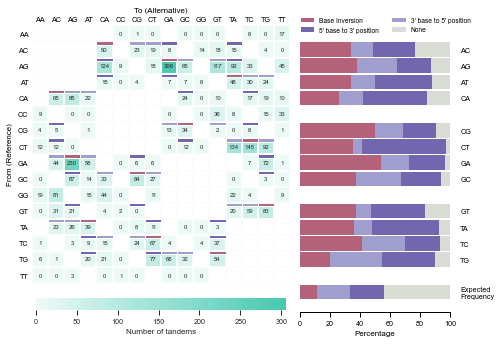

In [20]:
# tandem table (for a)
tandem_table_leiden_igv = get_tandem_table_from_summary(tandem_bysub_leiden_igv, approximate=True)

# tandems by inversions (for b)
tandems_by_invtype_leiden_igv = get_tandems_by_inversion_type(tandem_bysub_leiden_igv)
# get cumsum (it will be needed in the barplot)
tandems_by_invtype_leiden_igv["gcs"] = tandems_by_invtype_leiden_igv.groupby(["ref"])["perc"].cumsum()

fig_3 = heatmap_and_inversions(tandem_table_leiden_igv, tandems_by_invtype_leiden_igv)
#multisavefig(fig_3, "figs/", "fig_3")
fig_3.set_size_inches((17.5+2)/2.54,(12+1.4)/2.54)
for i in ["eps", "png", "pdf"]:
    fig_3.savefig(f"figs/{i}/fig_4.{i}",bbox_inches='tight',pad_inches = 0.05)

## Fig Nucleotide Context IGH nc -Target IGV c (+rev com)
- We used the top tandem (14) and it reverse complement from IGV because its more easy to interpret from the heatmap figure, then we converted the tandem to DBS cosmic format (78 strand agonostic types from COSMIC) and its contexts.

### Data Load

In [21]:
# IGV corrected
igv_ca = tandem_fulltable_bysub_leiden_igv.assign(n=lambda x: x.n_obs - x.n_sim)

In [22]:
# IGH no corrected
igh_ca = pd.read_csv("data/leiden_observed_tandems_IGHV_20nt.tsv", sep="\t")
igh_ca = igh_ca.query("size == 2")
igh_ca["context"] = igh_ca.context.str.extract(r"(.{,2}\.{2}.{,2})")
igh_ca = igh_ca.groupby(["ref", "alt", "context", "size"]).size().reset_index().rename(columns={0: "n"})

### Convert to cosmic format tandem (from 144 to 78 strand agnostic)

In [23]:
igv_cosmic = dataframe_canonizer(igv_ca)
igh_cosmic = dataframe_canonizer(igh_ca)

In [24]:
# top 10 mutations using IGV (we choose the most frequent mutations from IGV and we plot the conext of IGH)
top_10_tandems_igv_cosmic = get_top_tandem_mutations(igv_cosmic, 14)

# get df ready to plot
df_mut_context = get_tandem_context_perc(igh_cosmic, top_10_tandems_igv_cosmic, sorted_by_list=True)
df_mut_context.to_csv("output/df_mut_context.csv")

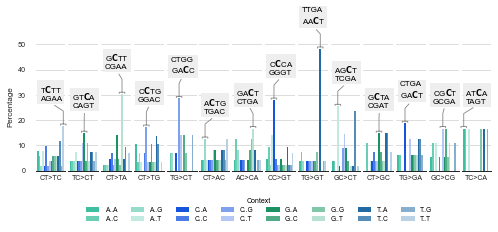

In [25]:
fig_4_h = mutation_context_barplot(df_mut_context)
#multisavefig(fig_4_h, "figs/", "M4a_h")
fig_4_h.set_size_inches((17.5-1.25)/2.54,(7-1.67)/2.54)
for i in ["eps", "png", "pdf"]:
    fig_4_h.savefig(f"figs/{i}/fig_5_canonical.{i}",bbox_inches='tight',pad_inches = 0.08)

## Fig Context p-value

In [26]:
# Add a column with TRUE/FALSE and tandem
igh_nc_pr["in_ref"] = igh_nc_pr.alt_germ4 != -1

In [27]:
%%R -i igh_nc_pr

# Summary of tandem ad presence in germline
germ_sum <- igh_nc_pr %>%
        group_by(tandem, in_ref) %>%
        summarise(value = sum(n,na.rm = TRUE)) 

UsageError: Cell magic `%%R` not found.


In [ ]:
%%R -i top_10_tandems_igv_cosmic
        
# #Define list 10 top tandem (order by desc presence in germline) and filter original df
top_tandem_mutations <- filter(germ_sum, tandem %in% top_10_tandems_igv_cosmic) %>%
                          mutate(perc = round(value * 100 / sum(value),2))
    
##changer order variable 
top_tandem_mutations$tandem <- factor(top_tandem_mutations$tandem, levels=c(top_10_tandems_igv_cosmic))

In [ ]:
# %%R
# ## df for statistics analysis
# stat_tandem <- top_tandem_mutations %>%
#                    select(-perc) %>%
#                   spread(in_ref, value)  # spread the value of false and true in columns

# stat_tandem <- column_to_rownames(stat_tandem, var="tandem")
# stat_tandem <- as.data.frame(t(stat_tandem))

# ## Proportion test
# prop_test <- sapply(stat_tandem, function(x) prop.test(x[2], sum(x), p=0.5, alternative ="greater")$p.value )
# prop_test

In [ ]:
%%R -w 17.5 -h 11.4 -u cm 
# bol <- plot_in_ref(top_tandem_mutations)
# #ggsave("figs/pdf/fig_4b.pdf", width = 17.5,height =6, units = "cm")
# bol

In [ ]:
#pdftops -level3 -eps fig4.pdf fig4.eps

## Fig Heatmap MSH

In [28]:
# calculate perc
tandem_bysub_rotterdam_msh['percent'] = (tandem_bysub_rotterdam_msh['n'] / tandem_bysub_rotterdam_msh['n'].sum()) * 100
tandem_bysub_rotterdam_msh.query("ref == 'AG'")

,ref,alt,size,n,percent
18,AG,CA,100,17.01402,1.629506
19,AG,CC,82,0.00000,0.000000
20,AG,CT,60,12.13196,1.161930
21,AG,GA,154,99.49178,9.528758
22,AG,GC,132,0.00000,0.000000
23,AG,GT,108,3.53218,0.338292
24,AG,TA,84,40.82024,3.909531
25,AG,TC,72,1.30440,0.124928
26,AG,TT,70,21.44176,2.053570


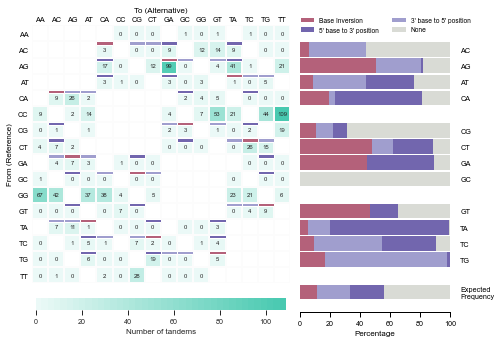

In [29]:
tandem_table_rotterdam_msh = get_tandem_table_from_summary(tandem_bysub_rotterdam_msh, approximate=True)

tandems_by_inv_type_msh = get_tandems_by_inversion_type(tandem_bysub_rotterdam_msh)
tandems_by_inv_type_msh["gcs"] = tandems_by_inv_type_msh.groupby(["ref"])["perc"].cumsum()

fig_s5 = heatmap_and_inversions(tandem_table_rotterdam_msh, tandems_by_inv_type_msh)
#multisavefig(fig_s5, "figs/", "S5")
fig_s5.set_size_inches((17.5+2)/2.54,(12+1.4)/2.54)
for i in ["eps", "png", "pdf"]:
    fig_s5.savefig(f"figs/{i}/fig_6.{i}",bbox_inches='tight',pad_inches = 0.05)

## Fig Heatmap UNG

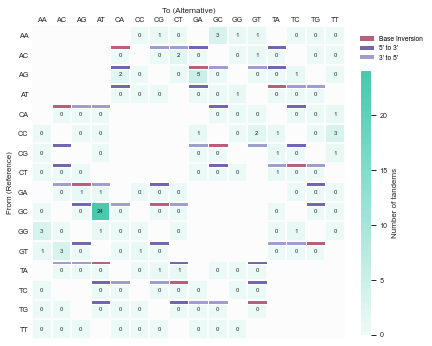

In [30]:
# Using no corrected data
tandem_table_rotterdam_ung = get_tandem_table_from_summary(tandem_bysub_rotterdam_ung_no_correc, approximate=True)
fig_s6 = tandem_heatmap(tandem_table_rotterdam_ung, annotate_inversions=True)
#multisavefig(fig_s6, "figs/", "S6")
fig_s6.set_size_inches((15.06-0.81)/2.54,(12+5.2)/2.54)
for i in ["eps", "png", "pdf"]:
    fig_s6.savefig(f"figs/{i}/fig_7.{i}",bbox_inches='tight',pad_inches = 0.05)

- ## Fig 8 Model (Illustrator)
- ## Fig 9 Model AG (Illustrator)
- ## Table 1 (Word)

# Supplementary Figures

## Fig S1 Distribution IGK

In [31]:
dbs_mutdata_igk = pd.read_csv("data/dns_analysis/dns_mutational_analysis_IgK.csv")

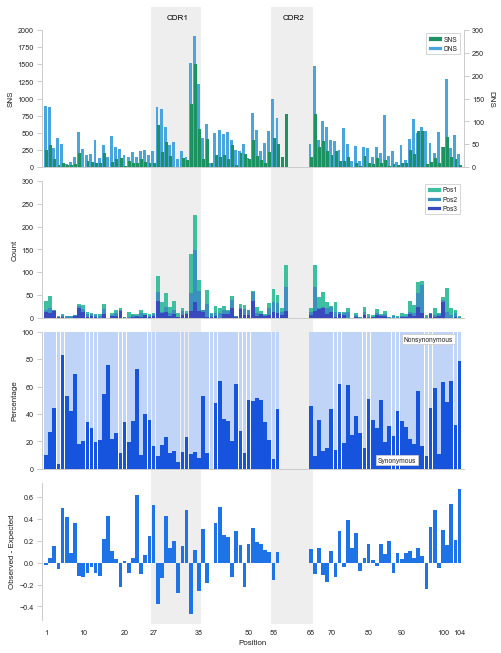

In [32]:
fig_s1 = position_barplots(dbs_mutdata_igk, [1, 10, 20, 27, 38, 50, 56, 65, 70, 80, 90, 100, 104], [0.975, 0.887])

# invisible axis to draw things accross all the subplots
overax = fig_s1.add_axes([0.1, 0.1, 0.845, 0.81])
overax.axis("off")
overax.set_zorder(-1)

# cdr1
overax.text(0.3, 0.98, "CDR1")
rect_cdr1 = patches.Rectangle((0.2678, 0.025), 0.1081, 0.975, color="#eeeeee", lw=0)
overax.add_patch(rect_cdr1)

# cdr2
overax.text(0.553, 0.98, "CDR2")
rect_cdr2 = patches.Rectangle((0.5285, 0.025), 0.09, 0.975, color="#eeeeee", lw=0)
overax.add_patch(rect_cdr2)

#multisavefig(fig_s1, "figs/", "S1")
fig_s1.set_size_inches((17.5+1.7)/2.54,(22.8+4.76)/2.54)
for i in ["eps", "png", "pdf"]:
    fig_s1.savefig(f"figs/{i}/fig_S1.{i}",bbox_inches='tight',pad_inches = 0.05)

## Fig S2 Distribution IGL

In [33]:
dbs_mutdata_igl = pd.read_csv("data/dns_analysis/dns_mutational_analysis_IgL.csv")

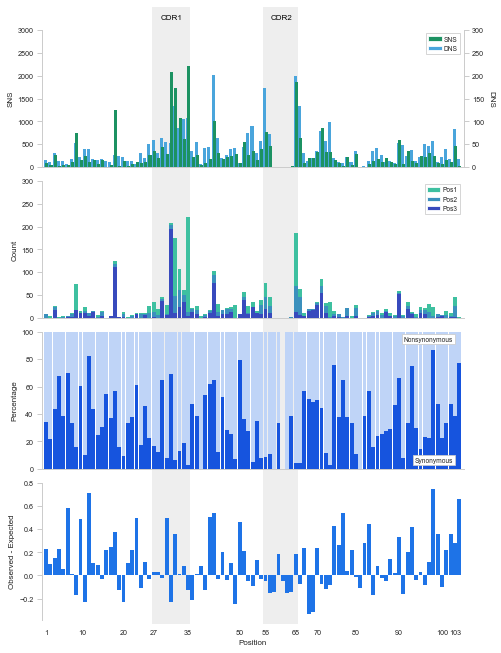

In [34]:
fig_s2 = position_barplots(dbs_mutdata_igl, [1, 10, 20, 27, 38, 50, 56, 65, 70, 80, 90, 100, 103], [0.975, 0.975])

# invisible axis to draw things accross all the subplots
overax = fig_s2.add_axes([0.1, 0.1, 0.845, 0.81])
overax.axis("off")
overax.set_zorder(-1)

# cdr1
overax.text(0.289, 0.98, "CDR1")
rect_cdr1 = patches.Rectangle((0.2684, 0.025), 0.084, 0.975, color="#eeeeee", lw=0)
overax.add_patch(rect_cdr1)

# cdr2
overax.text(0.527, 0.98, "CDR2")
rect_cdr2 = patches.Rectangle((0.5115, 0.025), 0.0747, 0.975, color="#eeeeee", lw=0)
overax.add_patch(rect_cdr2)

#multisavefig(fig_s2, "figs/", "S2")
fig_s2.set_size_inches((17.5+1.7)/2.54,(22.8+4.76)/2.54)
for i in ["eps", "png", "pdf"]:
    fig_s2.savefig(f"figs/{i}/fig_S2.{i}",bbox_inches='tight',pad_inches = 0.05)

## Fig S3 A

In [35]:
%%R #data from Marvyn
# C in transcribed
c_in_trans <-c(1277,541,429,387,374)
# Reverse complement without C
no_c <-c(568,200,304,383,220)
paired <- c("AG","GA","GT","TG","GG","AG","GA","GT","TG","GG") 
# Create a data frame,
strand_bias <- data.frame( 
                group = rep(c("C in transcribed\nstrand", "Reverse complement \n without C"), each = 5),
                mut = c(c_in_trans,  no_c),
                paired)

UsageError: Cell magic `%%R` not found.


In [ ]:
%%R
# Compute t-test
res <- t.test(mut ~ group, data = strand_bias, paired = TRUE)
res$p.value

In [ ]:
%%R -w 15 -h 10 -u cm 

#changer order variable 
strand_bias$paired <- factor(strand_bias$paired, levels=c("AG","GA","GT","TG","GG"))

lin <- plot_strand_bias(strand_bias) +
annotate("text", x = 2.1, y = 1262 , label = paste0("Paired t-test p= ", round(res$p.value,3)), size = 2.9,family="Arial") +
s_theme()
#ggsave("figs/jem/pdf/fig_S3.pdf", width = 8.5,height =10, units = "cm") #dosent work
ggsave("figs/png/fig_S3.png", width = 8.5,height =10, units = "cm")

## Fig S3 B #without correction IGH

In [36]:
# add aid motifs in each position to tandems
tandem_bysubcxt_leiden_igh_nc["aid_motif_pos1"] = tandem_bysubcxt_leiden_igh_nc.apply(
    lambda x: get_aid_pattern(x.ref, x.alt, x.context, pos=0), axis=1
)
tandem_bysubcxt_leiden_igh_nc["aid_motif_pos2"] = tandem_bysubcxt_leiden_igh_nc.apply(
    lambda x: get_aid_pattern(x.ref, x.alt, x.context, pos=1), axis=1
)

In [37]:
motif_matrix = get_aid_motif_matrix(tandem_bysubcxt_leiden_igh_nc)
motif_matrix.to_csv("aid.csv")

In [38]:
%%R -i motif_matrix
#Create df with aid motif fw and rv
aid_mo <- read.csv("aid.csv")
aid_mo <- aid_mo %>%
          gather(-aid_motif_pos1, key="aid_motif_pos2", value="Tandem") %>%
          mutate(strand_1=case_when( grepl("*_fw",aid_motif_pos1) ~ "Coding strand",
                                     grepl("*_rev",aid_motif_pos1) ~ "Template strand",
                                     TRUE ~ "None")) %>%
          mutate(strand_2=case_when( grepl("*_fw",aid_motif_pos2) ~ "Coding strand",
                                     grepl("*_rev",aid_motif_pos2) ~ "Template strand",
                                     TRUE ~ "None")) %>%
          drop_na() 

UsageError: Cell magic `%%R` not found.


In [ ]:
%%R
#changer order variable 
aid_mo$aid_motif_pos2 <- factor(aid_mo$aid_motif_pos2, levels=c("WRCY_fw","WRCY_rev","WA_fw","WA_rev","RCG_rev","RCG_fw","None"))
aid_mo$strand_1 <- factor(aid_mo$strand_1, levels=c("Coding strand","Template strand","None"))
aid_mo$strand_2 <- factor(aid_mo$strand_2, levels=c("Coding strand","Template strand","None"))

aid_heatmap <- plot_aid_motifs(aid_mo) 

ggsave("figs/png/fig_S3B.png",width = 8,  height = 8,  units = "cm")
aid_heatmap
# for (i in c( "pdf")){ #"eps", "png",
#   ggsave(paste0("figs/jem/",i,"/fig_S4_B.",i) width = 8.5,height =10, units = "cm")
# }

### Metrics about AID motifs analysis

In [39]:
total_fw = (
    motif_matrix.loc[motif_matrix.index.str.contains("fw|None"), motif_matrix.columns.str.contains("fw|None")]
    .sum()
    .sum()
)
total_fw

751.0

In [40]:
total_rev = (
    motif_matrix.loc[motif_matrix.index.str.contains("rev$|None"), motif_matrix.columns.str.contains("rev$|None")]
    .sum()
    .sum()
)
total_rev

798.0

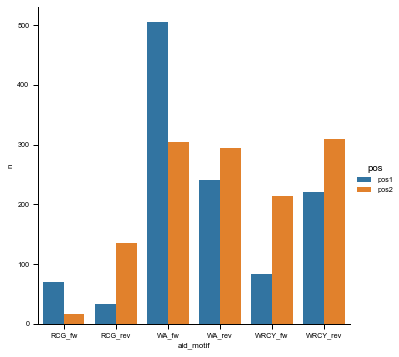

In [41]:
df = motif_matrix
pos1 = df[df.index != "None"].sum(axis=1)
pos2 = df.drop(columns=["None"]).sum(axis=0)
df_sum = (
    pd.DataFrame({"pos1": pos1, "pos2": pos2})
    .stack()
    .reset_index()
    .rename(columns={"level_0": "aid_motif", "level_1": "pos", 0: "n"})
)
sns.catplot(data=df_sum, x="aid_motif", y="n", hue="pos", kind="bar")

In [42]:
# How many in pos 1
df_sum.loc[df_sum['pos'] == 'pos1', 'n'].sum()

1151.0

In [43]:
# How many in pos 2
df_sum.loc[df_sum['pos'] == 'pos2', 'n'].sum()

1274.0

In [44]:
# How many are pos1 of the tandem (only)
motif_matrix.sum(axis = 1, skipna = True)

aid_motif_pos1
None        749.0
RCG_fw       69.0
RCG_rev      33.0
WA_fw       505.0
WA_rev      241.0
WRCY_fw      83.0
WRCY_rev    220.0
dtype: float64

In [45]:
# How many are pos2 of the tandem (only)
motif_matrix.sum(axis = 0, skipna = True)

aid_motif_pos2
None        626.0
RCG_fw       17.0
RCG_rev     135.0
WA_fw       305.0
WA_rev      295.0
WRCY_fw     213.0
WRCY_rev    309.0
dtype: float64

### Metrics about cytosines in ref and alt in ref

In [46]:
percs = (
    igh_nc_pr.assign(x=lambda x: ( (x.c_up.isin([0,1,2,3]))| (x.g_dw.isin([0,1,2,3]))   )) # (~x.alt_germ8.isin([-1])) & (~x.alt_germ4.isin([-1]))
    .groupby("x")
    .agg({"n": "sum"})
    .assign(perc=lambda x: 100 * x.n / float(x.sum()))
    .reset_index()
)

percs

,x,n,perc
0,False,165,6.145251
1,True,2520,93.854749


In [47]:
percs_in_ref = (
    igh_nc_pr.assign(x=lambda x: ( (~x.alt_germ8.isin([-1]))   )) #  & (~x.alt_germ4.isin([-1]))
    .groupby("x")
    .agg({"n": "sum"})
    .assign(perc=lambda x: 100 * x.n / float(x.sum()))
    .reset_index()
)

percs_in_ref

,x,n,perc
0,False,1458,54.301676
1,True,1227,45.698324


### Additional analysis about more frequent tetramers

In [48]:
# IGH no corrected
agca = (
    tandem_bysubcxt_leiden_igh_nc.assign(
        mutation=lambda x: x.ref + ">" + x.alt,
        germ4=lambda x: x.context.str[1:2] + x.ref + x.context.str[-2:-1],
    )
    .groupby(["mutation", "germ4"])
    .agg({"n": "sum"})
    .reset_index()
#    .query("mutation == 'AG>CA'")
    .sort_values("n", ascending=False)
)

[Text(0, 0, 'GC>AG AGCT'),
 Text(0, 0, 'AG>GA TAGT'),
 Text(0, 0, 'GC>AT AGCT'),
 Text(0, 0, 'AG>GA TAGC'),
 Text(0, 0, 'GC>CT AGCT'),
 Text(0, 0, 'GA>AG GGAG'),
 Text(0, 0, 'CT>TG CCTG'),
 Text(0, 0, 'CC>GT ACCT'),
 Text(0, 0, 'AG>GA CAGC'),
 Text(0, 0, 'GC>AT AGCA'),
 Text(0, 0, 'GC>CT AGCA'),
 Text(0, 0, 'AG>GA GAGC'),
 Text(0, 0, 'AG>GA GAGG'),
 Text(0, 0, 'GG>AA TGGT')]

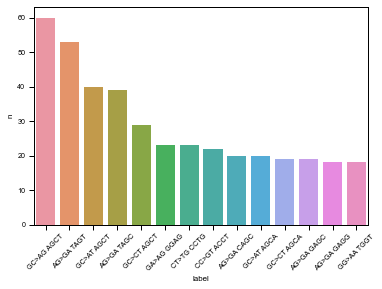

In [49]:
f = sns.barplot(data=agca.head(14).assign(label=lambda x: x.mutation + " " + x.germ4), x="label", y="n")
f.set_xticklabels(f.get_xticklabels(), rotation=45)
#plt.savefig("figs/jem/tetramers_IGH_nc.pdf")

## Fig SX Heatmap alt in ref

In [50]:
# df only with top tandems using IG(H)V corrected
#top_10_tandems_igh = get_top_tandem_mutations(tandem_bysub_leiden_igh, 14)
igh_nc_pr_top =igh_nc_pr[igh_nc_pr.tandem.isin(top_10_tandems_igv_cosmic)] #use the same list of tandem that in fig 5A

In [51]:
# Create df using the position where the alt was found in germ4
cnt = (
    igh_nc_pr_top.groupby(["tandem", "alt_germ4"])
    .agg({"n": "sum"})
    .query("n > 0")
    .unstack()
    .fillna(0)
)
cnt.columns = cnt.columns.droplevel().rename(None)

In [52]:
# L2 Normalization
# "automatic" way
cnt = pd.DataFrame(normalize(cnt, "l2",axis=0), columns=cnt.columns, index=cnt.index)

In [53]:
%%R -i cnt
#rename variables
names(cnt)[1:3] = c("No present", "Pos-1", "Pos t2")

UsageError: Cell magic `%%R` not found.


In [ ]:
%%R 
col_fun = circlize::colorRamp2(c(0,1), c("white", "orange"))
ht1 <- Heatmap(cnt, name = "Tandem in\ngermline", col = col_fun,cluster_rows = TRUE,cluster_columns = FALSE,row_names_gp = gpar(fontsize = 6),
               column_names_gp = gpar(fontsize =6),show_heatmap_legend = TRUE,
                            heatmap_legend_param = list(legend_direction = "horizontal",
    legend_width = unit(2., "cm"), title_position = "lefttop",title_gp = gpar(fontsize = 6),labels_gp = gpar(fontsize = 4)))

In [54]:
pupy = (
    igh_nc_pr_top[["tandem", "n"]]
    .assign(
        base=igh_nc_pr_top.germ4_pupy.apply( #define which context to use
            lambda x: "-".join(
                "py" if y in "CT" else "pu" if y in "AG" else "No"
                for y in x
                if y != "."
            )
        )
    )
    .groupby(["tandem", "base"])
    .agg({"n": "sum"})
    # filter 0 values before unstacking
    .query("n > 0")
    .unstack()
    .fillna(0)

)
pupy.columns = pupy.columns.droplevel().rename(None)

#remove pu and py columns flaitemente
pupy.drop(["pu"],axis=1,inplace=True) #"pu-pu-pu", "pu-py-pu","py-pu-py"

In [55]:
# L2 Normalization
pupy = pd.DataFrame(normalize(pupy, "l2", axis=0), columns=pupy.columns, index=pupy.index) # axis 0 rows

In [56]:
%%R -i pupy
col_fun = circlize::colorRamp2(c(0,1), c("white", "turquoise"))
ht2 <- Heatmap(pupy,name = "Tandem\ncontext", col=col_fun,cluster_rows = FALSE, km=2,cluster_columns = FALSE,row_title_gp=gpar(fontsize =6), row_names_gp = gpar(fontsize =6), 
               column_names_gp = gpar(fontsize =6), show_heatmap_legend = TRUE,
              heatmap_legend_param = list(legend_direction = "horizontal",
    legend_width = unit(2, "cm"), title_position = "lefttop",title_gp = gpar(fontsize = 6),labels_gp = gpar(fontsize = 4)))

UsageError: Cell magic `%%R` not found.


In [ ]:
%%R
#png("figs/jem/png/fig_S5B.png",width=8,height=8,units="cm",res=1200)
# ha = HeatmapAnnotation(
#     show_legend = c(FALSE, FALSE))
ht <- draw(ht2+ht1, heatmap_legend_side = "bottom")

grob = grid.grabExpr(draw(ht))

In [ ]:
%%R #Save heatmap using plot grid because I did not found another way to do it
#mo_ai <- plot_grid(lin, aid_heatmap, nrow = 1, align="w", labels = c("A","B"), label_size = 8) #, rel_heights = c(1.5, 2.2)
mo_ai_both <- plot_grid(grob, ncol = 1, labels = c('',''), label_size = 8, vjust=0,rel_heights = c(1.5, 2.2)) #, rel_heights = c(1.5, 2.2)
#mo_ai
mo_ai_both
#fig_save(mo_ai_both, filename = "figs/jem/pdf/fig_S3", formats = c("pdf"), width = 17.5,height=22.8, units = "cm", dpi = 600)
fig_save(mo_ai_both, filename = "figs/pdf/fig_S5B", formats = c("pdf"), width = 8,height=7, units = "cm", dpi = 600)
fig_save(mo_ai_both, filename = "figs/png/fig_S5B", formats = c("png"), width = 8,height=7, units = "cm", dpi = 600)

In [ ]:
#pdftops -level3 -eps fig_S3.pdf ../eps/fig_S3.eps

## Fig S4 Heatmap HD Rotterdam

In [57]:
# calculate perc
tandem_bysub_rotterdam_hd['percent'] = (tandem_bysub_rotterdam_hd['n'] / tandem_bysub_rotterdam_hd['n'].sum()) * 100
tandem_bysub_rotterdam_hd.query("ref == 'GA'")

,ref,alt,size,n,percent
72,GA,AC,118,25.14904,0.948705
73,GA,AG,122,21.58136,0.814121
74,GA,AT,84,3.88408,0.146520
75,GA,CC,118,1.61816,0.061042
76,GA,CG,128,0.00000,0.000000
77,GA,CT,94,0.00000,0.000000
78,GA,TC,98,10.02288,0.378096
79,GA,TG,104,4.82896,0.182164
80,GA,TT,64,2.17784,0.082155


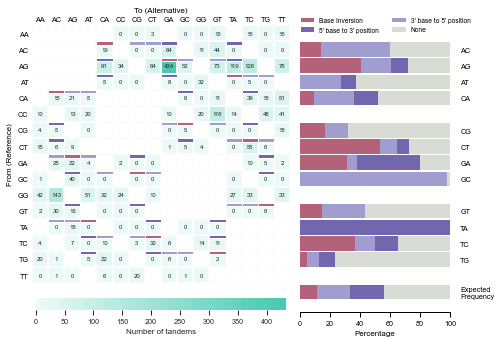

In [58]:
tandem_table_rotterdam_hd = get_tandem_table_from_summary(tandem_bysub_rotterdam_hd, approximate=True)

tandems_by_invtype_rotterdam_hd = get_tandems_by_inversion_type(tandem_bysub_rotterdam_hd)
tandems_by_invtype_rotterdam_hd["gcs"] = tandems_by_invtype_rotterdam_hd.groupby(["ref"])["perc"].cumsum()

fig_s7 = heatmap_and_inversions(tandem_table_rotterdam_hd, tandems_by_invtype_rotterdam_hd)
#multisavefig(fig_s7, "figs/", "S7")
fig_s7.set_size_inches((17.5+2)/2.54,(12+1.4)/2.54)
for i in ["eps", "png", "pdf"]:
    fig_s7.savefig(f"figs/{i}/fig_S4.{i}",bbox_inches='tight',pad_inches = 0.05)

# Supplementary Figures

## Table S7 Analysis Cosmic signatures

In [59]:
%%R -i tandem_bysubcxt_leiden_igh_nc
tan_cos <- tandem_bysubcxt_leiden_igh_nc %>%
           mutate(ref2=case_when(ref == "AA" ~ "TT", 
                                  ref == "AC" ~ "AC",
                                  ref == "AG" ~ "CT",
                                  ref == "AT" ~ "AT", ##
                                  ref == "CA" ~ "TG",
                                  ref == "CC" ~ "CC", ##
                                  ref == "CG" ~ "CG", ##
                                  ref == "CT" ~ "CT", ##
                                  ref == "GA" ~ "TC",
                                  ref == "GC" ~ "GC", ##
                                  ref == "GG" ~ "CC", ##
                                  ref == "GT" ~ "AC",
                                  ref == "TA" ~ "TA", ##
                                  ref == "TC" ~ "TC", ##
                                  ref == "TG" ~ "TG", ##
                                  ref == "TT" ~ "TT", ##
                                   TRUE ~ "Er")) %>%
             mutate(alt2=case_when(ref2 == "AC" & alt == "TG" ~ "CA",
                                   ref2 == "AC" & alt == "AG" ~ "CT",
                                   ref2 == "AC" & alt == "TC" ~ "GA",
                                   ref2 == "AC" & alt == "CC" ~ "GG",
                                  ref2 == "AC" & alt == "AC" ~ "GT",
                                  ref2 == "AC" & alt == "CA" ~ "TG",
                                  ref2 == "AC" & alt == "AA" ~ "TT",
                                  ref2 == "AT" & alt == "TG" ~ "CA",
                                  ref2 == "AT" & alt == "GG" ~ "CC",
                                  ref2 == "AT" & alt == "TC" ~ "GA",
                                  ref2 == "CC" & alt == "TT" ~ "AA",
                                  ref2 == "CC" & alt == "CT" ~ "AG",
                                  ref2 == "CC" & alt == "TC" ~ "GA",
                                  ref2 == "CC" & alt == "CC" ~ "GG",
                                  ref2 == "CC" & alt == "AC" ~ "GT",
                                  ref2 == "CC" & alt == "CA" ~ "TG",
                                  ref2 == "CC" & alt == "AA" ~ "TT",
                                  ref2 == "CG" & alt == "AC" ~ "GT",
                                  ref2 == "CG" & alt == "GA" ~ "TC",
                                  ref2 == "CG" & alt == "AA" ~ "TT",
                                  ref2 == "CT" & alt == "TT" ~ "AA",
                                  ref2 == "CT" & alt == "GT" ~ "AC",
                                  ref2 == "CT" & alt == "CT" ~ "AG",
                                  ref2 == "CT" & alt == "TC" ~ "GA",
                                  ref2 == "CT" & alt == "CC" ~ "GG",
                                  ref2 == "CT" & alt == "GA" ~ "TC",
                                  ref2 == "CT" & alt == "CA" ~ "TG",
                                  ref2 == "GC" & alt == "TT" ~ "AA",
                                  ref2 == "GC" & alt == "CT" ~ "AG",
                                  ref2 == "GC" & alt == "TG" ~ "CA",
                                  ref2 == "TA" & alt == "AG" ~ "CT",
                                  ref2 == "TA" & alt == "CC" ~ "GG",
                                  ref2 == "TA" & alt == "AC" ~ "GT",
                                  ref2 == "TC" & alt == "TT" ~ "AA",
                                  ref2 == "TC" & alt == "CT" ~ "AG",
                                  ref2 == "TC" & alt == "TG" ~ "CA",
                                  ref2 == "TC" & alt == "AG" ~ "CT",
                                  ref2 == "TC" & alt == "TC" ~ "GA",
                                  ref2 == "TC" & alt == "CC" ~ "GG",
                                  ref2 == "TC" & alt == "AC" ~ "GT",
                                  ref2 == "TG" & alt == "TT" ~ "AA",
                                  ref2 == "TG" & alt == "GT" ~ "AC",
                                  ref2 == "TG" & alt == "TG" ~ "CA",
                                  ref2 == "TG" & alt == "GG" ~ "CC",
                                  ref2 == "TG" & alt == "AG" ~ "CT",
                                  ref2 == "TG" & alt == "TC" ~ "GA",
                                  ref2 == "TG" & alt == "AC" ~ "GT",
                                  ref2 == "TT" & alt == "TT" ~ "AA",
                                  ref2 == "TT" & alt == "GT" ~ "AC",
                                  ref2 == "TT" & alt == "CT" ~ "AG",
                                  ref2 == "TT" & alt == "TG" ~ "CA",
                                  ref2 == "TT" & alt == "GG" ~ "CC",
                                  ref2 == "TT" & alt == "TC" ~ "GA",
                                  ref2 == "TT" & alt == "CC" ~ "GG",
                                  TRUE ~ alt)) %>%
        mutate(tandem2=paste0(ref2,">",alt2))

UsageError: Cell magic `%%R` not found.


In [ ]:
%%R
#Summary of tandem 
summ <- tan_cos %>%
         group_by(tandem2) %>%
         summarise(value = sum(n,na.rm = TRUE)) %>%
        ungroup() %>%
        as.data.frame()

####  Doublet Base Substitution (DBS) Signatures v3

In [ ]:
%%R
cosine_dist <- function(x, y) {
  return(1 - as.numeric(x %*% y / sqrt(x %*% x * y %*% y)))
}
get_cross_similarity <- function(sigs_a, sigs_b) {
  dists <- sapply(1:ncol(sigs_a), function(x) {
    sapply(1:ncol(sigs_b), function(y) {
      1 - cosine_dist(sigs_a[, x], sigs_b[, y])
    })
  })

  colnames(dists) <- colnames(sigs_a)
  rownames(dists) <- colnames(sigs_b)

  return(dists)
}

In [ ]:
%%R
cosmic_dbs <- read.csv("data/DBS_signatures_COSMIC_v3.1.csv") 
cosmic_dbs <- remove_rownames(cosmic_dbs) 

In [ ]:
%%R
# df scaled by column
summ_scale <- summ[-(1:1)] %>%
              mutate(IGV_sig=value*1/sum(value))

In [ ]:
%%R
#calculate similarity
similarities <- as.data.frame(get_cross_similarity(summ_scale[-(1:1)], cosmic_dbs[-(1:1)]))

In [ ]:
%%R
similarities
write.csv(similarities, "figs/csv/cos_sim.csv")

## pie

In [ ]:
%%R -w 20 -h 5 -u cm
#pdf(height=1.7, width=3.33, pointsize=7,family="Arial",file="figs/fig_S6?.pdf")
corr_pal <- colorRampPalette(c("#7F0000", "red", "#FF7F00", "yellow", "white",
                           "white", "#49bd83", "#49bdbd", "#4983bd"))
pie <- corrplot(t(similarities), method = "pie", tl.col = "black", tl.pos = "lt", addgrid.col = NA, cl.lim = c(0, 1), col = corr_pal(8),  is.corr = FALSE, 
                outline = "white",  addCoef.col = "black",
                number.cex=0.8,
                number.digits = 2,
                order = "original",
                tl.cex=1.1,
                mar = c(0,0,1,0)
                )
#dev.off()

### Supplementary sample random

In [60]:
tandem_bysub_leiden_igv_random = pd.read_csv("output/tandem_bysub_leiden_igv_random.csv")

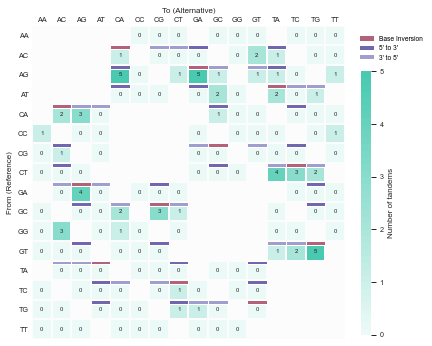

In [61]:
# Using random sample
tandem_table_leiden_random = get_tandem_table_from_summary(tandem_bysub_leiden_igv_random, approximate=True)
#tandem_table_leiden_random = tandem_table_leiden_random.fillna(0)
fig_sX = tandem_heatmap(tandem_table_leiden_random, annotate_inversions=True)
#multisavefig(fig_s6, "figs/", "S6")
fig_sX.set_size_inches((15.06-0.81)/2.54,(12+5.2)/2.54)
for i in ["eps", "png", "pdf"]:
    fig_sX.savefig(f"figs/{i}/fig_S6.{i}",bbox_inches='tight',pad_inches = 0.05)

In [62]:
tandem_bysub_rot_random = pd.read_csv("output/tandem_bysub_rotterdam_hd_random.csv")

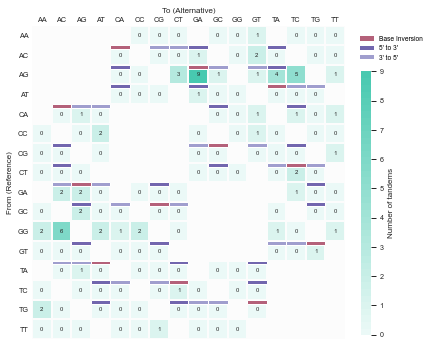

In [63]:
# Using random sample
tandem_table_rot_random = get_tandem_table_from_summary(tandem_bysub_rot_random, approximate=True)
fig_sX = tandem_heatmap(tandem_table_rot_random, annotate_inversions=True)
#multisavefig(fig_s6, "figs/", "S6")
fig_sX.set_size_inches((15.06-0.81)/2.54,(12+5.2)/2.54)
for i in ["eps", "png", "pdf"]:
    fig_sX.savefig(f"figs/{i}/fig_S6B.{i}",bbox_inches='tight',pad_inches = 0.05)

In [64]:
tandem_bysub_leiden_igv_random = pd.read_csv("output/tandem_bysub_rotterdam_msh_random.csv")

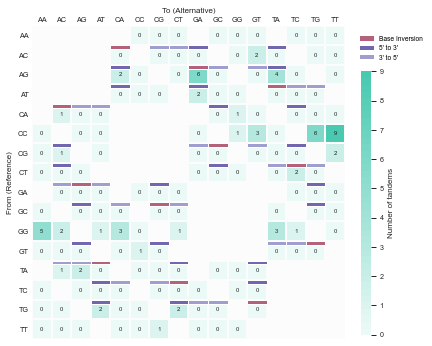

In [65]:
# Using random sample
tandem_table_leiden_random = get_tandem_table_from_summary(tandem_bysub_leiden_igv_random, approximate=True)
#tandem_table_leiden_random = tandem_table_leiden_random.fillna(0)
fig_sX = tandem_heatmap(tandem_table_leiden_random, annotate_inversions=True)
#multisavefig(fig_s6, "figs/", "S6")
fig_sX.set_size_inches((15.06-0.81)/2.54,(12+5.2)/2.54)
for i in ["eps", "png", "pdf"]:
    fig_sX.savefig(f"figs/{i}/fig_S6C.{i}",bbox_inches='tight',pad_inches = 0.05)

# Fig Heatmap IGH-L-K (Supplementary)

### IGHV Leiden

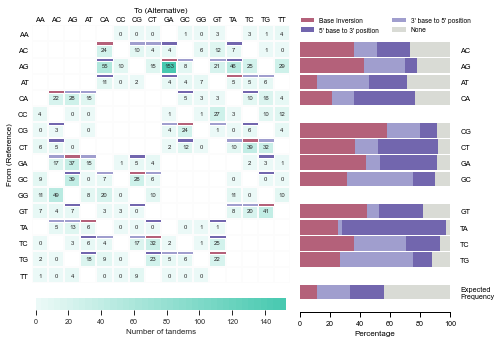

In [66]:
# tandem table (for a)
tandem_table_leiden_igh = get_tandem_table_from_summary(tandem_bysub_leiden_igh, approximate=True)

# tandems by inversions (for b)
tandems_by_invtype_leiden_igh = get_tandems_by_inversion_type(tandem_bysub_leiden_igh)
# get cumsum (it will be needed in the barplot)
tandems_by_invtype_leiden_igh["gcs"] = tandems_by_invtype_leiden_igh.groupby(["ref"])["perc"].cumsum()

fig_3 = heatmap_and_inversions(tandem_table_leiden_igh, tandems_by_invtype_leiden_igh)
#multisavefig(fig_3, "figs/", "fig_3")
fig_3.set_size_inches((17.5+2)/2.54,(12+1.4)/2.54)
for i in ["eps", "png", "pdf"]:
    fig_3.savefig(f"figs/{i}/fig_S3A_heatmap.{i}",bbox_inches='tight',pad_inches = 0.05)

### IGKV Leiden

In [67]:
tandem_fulltable_bysub_leiden_igk = load_tandem_info(
    "data/leiden_observed_tandems_IGKV.tsv",
    "data/leiden_simulation_IGKV_count_mutation_context.tsv"
)

# some tables ready to use them later
tandem_bysub_leiden_igk = get_corrected_df(tandem_fulltable_bysub_leiden_igk, ["ref", "alt"])

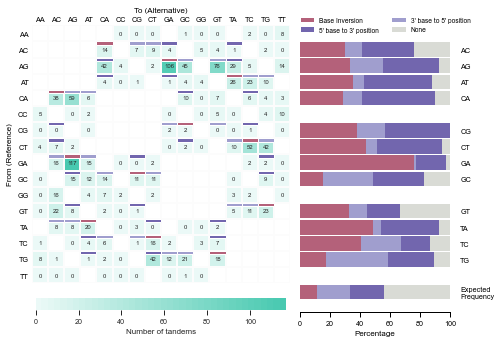

In [68]:
# tandem table (for a)
tandem_table_leiden_igk = get_tandem_table_from_summary(tandem_bysub_leiden_igk, approximate=True)

# tandems by inversions (for b)
tandems_by_invtype_leiden_igk = get_tandems_by_inversion_type(tandem_bysub_leiden_igk)
# get cumsum (it will be needed in the barplot)
tandems_by_invtype_leiden_igk["gcs"] = tandems_by_invtype_leiden_igk.groupby(["ref"])["perc"].cumsum()

fig_3 = heatmap_and_inversions(tandem_table_leiden_igk, tandems_by_invtype_leiden_igk)
#multisavefig(fig_3, "figs/", "fig_3")
fig_3.set_size_inches((17.5+2)/2.54,(12+1.4)/2.54)
for i in ["eps", "png", "pdf"]:
    fig_3.savefig(f"figs/{i}/fig_S3B_heatmap.{i}",bbox_inches='tight',pad_inches = 0.05)

### IGLV Leiden

In [69]:
tandem_fulltable_bysub_leiden_igl = load_tandem_info(
    "data/leiden_observed_tandems_IGLV.tsv",
    "data/leiden_simulation_IGLV_count_mutation_context.tsv"
)

# some tables ready to use them later
tandem_bysub_leiden_igl = get_corrected_df(tandem_fulltable_bysub_leiden_igl, ["ref", "alt"])

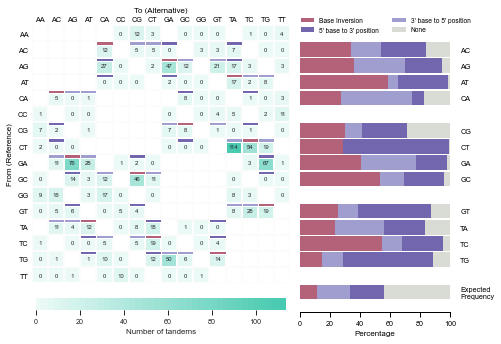

In [70]:
# tandem table (for a)
tandem_table_leiden_igl = get_tandem_table_from_summary(tandem_bysub_leiden_igl, approximate=True)

# tandems by inversions (for b)
tandems_by_invtype_leiden_igl = get_tandems_by_inversion_type(tandem_bysub_leiden_igl)
# get cumsum (it will be needed in the barplot)
tandems_by_invtype_leiden_igl["gcs"] = tandems_by_invtype_leiden_igl.groupby(["ref"])["perc"].cumsum()

fig_3 = heatmap_and_inversions(tandem_table_leiden_igl, tandems_by_invtype_leiden_igl)
#multisavefig(fig_3, "figs/", "fig_3")
fig_3.set_size_inches((17.5+2)/2.54,(12+1.4)/2.54)
for i in ["eps", "png", "pdf"]:
    fig_3.savefig(f"figs/{i}/fig_S3C_heatmap.{i}",bbox_inches='tight',pad_inches = 0.05)